# XAI — MDI + SHAP — XGBoost

MDI + SHAP para el modelo **XGBoost** sobre las 4 herramientas (CIC, Nemea, Tstat, Tshark).

In [11]:
# ============================================================
# CELDA 0 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import shap
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

shap.initjs()
print('✓ Imports OK')
print(f'  shap: {shap.__version__}')


✓ Imports OK
  shap: 0.49.1


In [12]:
# ============================================================
# CELDA 1 — CONFIGURACIÓN
# ============================================================

RUTA_BASE = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')

CLASES = [
    'BenignTraffic', 'DictionaryBruteForce', 'Recon',
    'Mirai', 'Spoofing', 'DoS', 'DDoS', 'Web'
]

HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']

SEED = 42
TEST_SIZE = 0.2

COLS_ELIMINAR = {
    'CIC':    ['Label', 'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port',
               'Timestamp', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
               'URG Flag Cnt', 'CWR Flag Count', 'ECE Flag Cnt',
               'Fwd Bytes/Bulk Avg', 'Fwd Bulk Rate Avg', 'Fwd Packet/Bulk Avg'],
    'Nemea':  ['LABEL', 'uint64 FLOW_ID', 'macaddr DST_MAC', 'macaddr SRC_MAC',
               'ipaddr SRC_IP', 'ipaddr DST_IP', 'uint16 SRC_PORT', 'uint16 DST_PORT',
               'time TIME_FIRST', 'time TIME_LAST',
               'time* DBI_BRST_TIME_START', 'time* DBI_BRST_TIME_STOP',
               'time* SBI_BRST_TIME_START', 'time* SBI_BRST_TIME_STOP'] +
              [f'time_PPI_PKT_TIMES_{i}' for i in range(30)],
    'Tstat':  ['etiqueta', 'fqdn', 'c_tls_SNI', 's_tls_SCN', 'c_npnalpn', 's_npnalpn',
               'c_tls_sesid', 'dns_rslv', 'last', 'c_first', 's_first', 'c_last', 's_last',
               'c_first_ack', 's_first_ack', 'c_last_handshakeT', 's_last_handshakeT',
               'c_appdataT', 's_appdataT', 'req_tm', 'res_tm', 's_first_abs',
               'c_ip', 's_ip', 'c_port', 's_port', 'first', 'c_first_abs'],
    'Tshark': ['category', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'start_epoch'],
}

TOP_N = 15
SHAP_SAMPLE = 500

GUARDAR_FIGURAS = True
RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/MDI')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

print('✓ Configuración cargada')
print(f'  Base de datos: {RUTA_BASE}')
print(f'  Existe:        {RUTA_BASE.exists()}')


✓ Configuración cargada
  Base de datos: /home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos
  Existe:        True


In [13]:
# ============================================================
# CELDA 2 — FUNCIÓN DE CARGA Y LIMPIEZA
# ============================================================

def cargar_herramienta(herramienta):
    dfs = []
    for clase in CLASES:
        ruta = RUTA_BASE / clase / f'{herramienta}.csv'
        if not ruta.exists():
            print(f'  ⚠ No encontrado: {ruta}')
            continue
        df_tmp = pd.read_csv(ruta, low_memory=False)
        df_tmp['Label_Modelo'] = clase
        dfs.append(df_tmp)

    df = pd.concat(dfs, ignore_index=True)

    cols_por_clase = [set(pd.read_csv(RUTA_BASE / c / f'{herramienta}.csv',
                                      nrows=0, low_memory=False).columns)
                      for c in CLASES
                      if (RUTA_BASE / c / f'{herramienta}.csv').exists()]
    cols_comunes = set.intersection(*cols_por_clase) if cols_por_clase else set(df.columns)
    df = df[[c for c in df.columns if c in cols_comunes or c == 'Label_Modelo']]

    cols_drop = [c for c in COLS_ELIMINAR.get(herramienta, []) if c in df.columns]
    df = df.drop(columns=cols_drop)

    if herramienta == 'Nemea':
        quic_cols = [c for c in df.columns if 'QUIC' in c.upper()]
        df = df.drop(columns=quic_cols)

    y = df['Label_Modelo']
    X = df.drop(columns=['Label_Modelo'])

    # Eliminar columnas cuyo contenido sea listas serializadas como string
    cols_lista = [c for c in X.columns
                  if X[c].dtype == object and X[c].dropna().astype(str).str.startswith('[').any()]
    if cols_lista:
        print(f'  ⚠ Columnas-lista eliminadas: {cols_lista}')
        X = X.drop(columns=cols_lista)

    for col in X.select_dtypes(include='object').columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    ctes = [c for c in X.columns if X[c].nunique() <= 1]
    X = X.drop(columns=ctes)

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)
    # Forzar todo a float64 (evita strings de notación científica que rompan SHAP)
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

    feature_names = list(X.columns)
    print(f'[{herramienta}] Shape X: {X.shape} | Clases: {y.nunique()}')
    if ctes:
        print(f'  Constantes eliminadas: {len(ctes)}')
    return X, y, feature_names

print('✓ Función de carga definida')


✓ Función de carga definida


In [14]:
# ============================================================
# CELDA 3 — FUNCIÓN PRINCIPAL: ENTRENA + MDI + SHAP
# Usa booster nativo de XGBoost para evitar bug de parsing
# de strings en versiones recientes de XGBoost + SHAP.
# ============================================================

import xgboost as xgb

import json

def limpiar_booster_xgb(modelo):
    booster = modelo.get_booster()
    config = json.loads(booster.save_config())
    try:
        lmp = config['learner']['learner_model_param']
        # En XGBoost 3.x multiclase, base_score es un array serializado
        # que SHAP 0.49 no puede parsear → lo eliminamos del config
        if 'base_score' in lmp:
            del lmp['base_score']
        booster.load_config(json.dumps(config))
    except Exception as e:
        print(f'  ⚠ limpiar_booster: {e}')
    return booster

def analizar_modelo(nombre_modelo, modelo_cls, kwargs_modelo, herramienta, X, y, feature_names):
    print(f'\n  [{herramienta}] Entrenando {nombre_modelo}...')

    le_y = LabelEncoder()
    y_enc = le_y.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y_enc, test_size=TEST_SIZE, random_state=SEED, stratify=y_enc
    )

    modelo = modelo_cls(**kwargs_modelo)
    modelo.fit(X_train, y_train)
    f1 = f1_score(y_test, modelo.predict(X_test), average='macro')
    print(f'  [{herramienta}] F1 macro (test): {f1:.4f}')

    # ── MDI ─────────────────────────────────────────────────
    if hasattr(modelo, 'feature_importances_'):
        mdi = pd.Series(modelo.feature_importances_, index=feature_names)
        mdi_top = mdi.nlargest(TOP_N)
        fig, ax = plt.subplots(figsize=(8, 6))
        mdi_top.sort_values().plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'MDI Top-{TOP_N} — {nombre_modelo} / {herramienta}', fontsize=12)
        ax.set_xlabel('Importancia (MDI)', fontsize=11)
        ax.tick_params(axis='y', labelsize=13)
        ax.tick_params(axis='x', labelsize=13)
        plt.tight_layout()
        if GUARDAR_FIGURAS:
            fig.savefig(RUTA_FIGURAS / f'MDI_{nombre_modelo}_{herramienta}.pdf', dpi=150)
        plt.show()
        plt.close()
    else:
        mdi_top = None

    # ── SHAP ────────────────────────────────────────────────
    print(f'  [{herramienta}] Calculando SHAP...')
    X_shap = X_test[:SHAP_SAMPLE]

    shap_values = None
    try:
        booster = limpiar_booster_xgb(modelo)
        explainer = shap.TreeExplainer(booster)
        shap_values = explainer.shap_values(X_shap)
        print(f'  [{herramienta}] SHAP OK (booster limpio)')
    except Exception as e1:
        print(f'  ⚠ Booster limpio falló: {e1}')
        try:
            explainer = shap.TreeExplainer(modelo, model_output='raw')
            shap_values = explainer.shap_values(X_shap)
            print(f'  [{herramienta}] SHAP OK (model_output=raw)')
        except Exception as e2:
            print(f'  ⚠ model_output=raw falló: {e2}')
            try:
                explainer = shap.Explainer(modelo, X_shap)
                sv = explainer(X_shap)
                shap_values = sv.values
                print(f'  [{herramienta}] SHAP OK (shap.Explainer genérico)')
            except Exception as e3:
                print(f'  ✗ Todos los intentos SHAP fallaron: {e3}')
                shap_values = None

    if shap_values is None:
        print(f'  [{herramienta}] Saltando plots SHAP.')
        importancia_shap = pd.Series(dtype=float)
    else:
        # ── Bar plot (|SHAP|, igual que antes) ──────────────
        if isinstance(shap_values, list):
            shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
        else:
            if shap_values.ndim == 3:
                shap_abs_mean = np.mean(np.abs(shap_values), axis=2)
            else:
                shap_abs_mean = np.abs(shap_values)

        fig, ax = plt.subplots(figsize=(8, 6))
        shap.summary_plot(
            shap_abs_mean, X_shap,
            feature_names=feature_names,
            max_display=TOP_N,
            plot_type='bar',
            show=False
        )
        plt.title(f'SHAP Top-{TOP_N} — {nombre_modelo} / {herramienta}', fontsize=12)
        plt.tight_layout()
        if GUARDAR_FIGURAS:
            fig.savefig(RUTA_FIGURAS / f'SHAP_bar_{nombre_modelo}_{herramienta}.pdf', dpi=150)
        plt.show()
        plt.close()

        importancia_shap = pd.Series(
            shap_abs_mean.mean(axis=0), index=feature_names
        ).nlargest(15)

    return {
        'modelo':           nombre_modelo,
        'herramienta':      herramienta,
        'f1':               f1,
        'mdi_top':          mdi_top,
        'shap_top':         importancia_shap,
        # ── NUEVO: guardamos los valores crudos para beeswarm y comparación ──
        'shap_values_raw':  shap_values,
        'X_shap_raw':       X_shap,
        'feature_names':    feature_names,
    }

print('✓ analizar_modelo actualizada (guarda shap_values_raw y X_shap_raw)')

✓ analizar_modelo actualizada (guarda shap_values_raw y X_shap_raw)



  XGBoost — CIC


[CIC] Shape X: (27848, 69) | Clases: 8
  Constantes eliminadas: 1

  [CIC] Entrenando XGBoost...
  [CIC] F1 macro (test): 0.7380


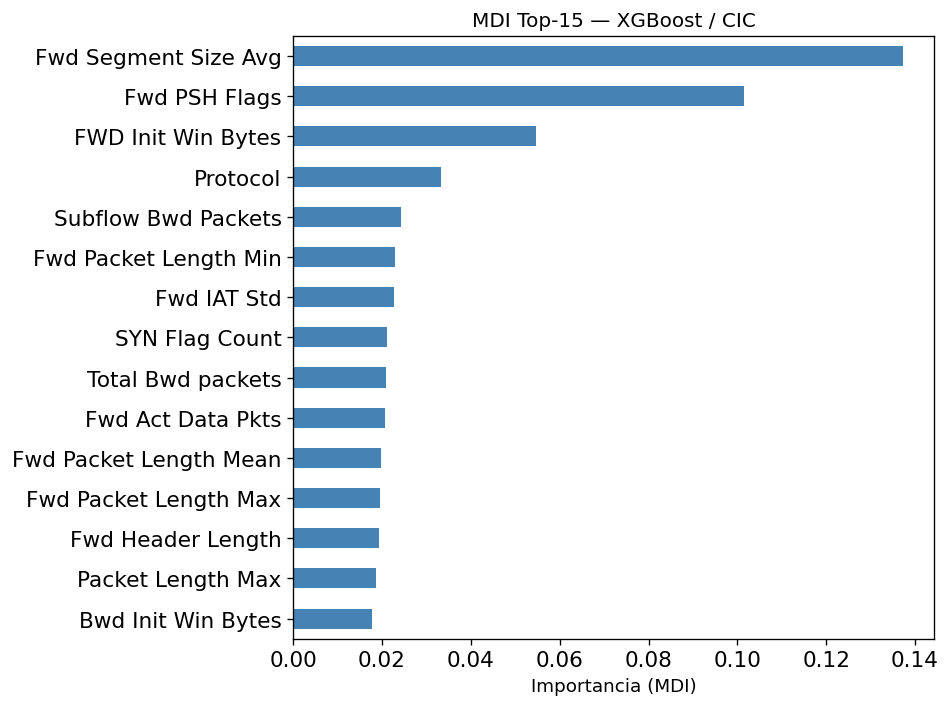

  [CIC] Calculando SHAP...
  [CIC] SHAP OK (booster limpio)


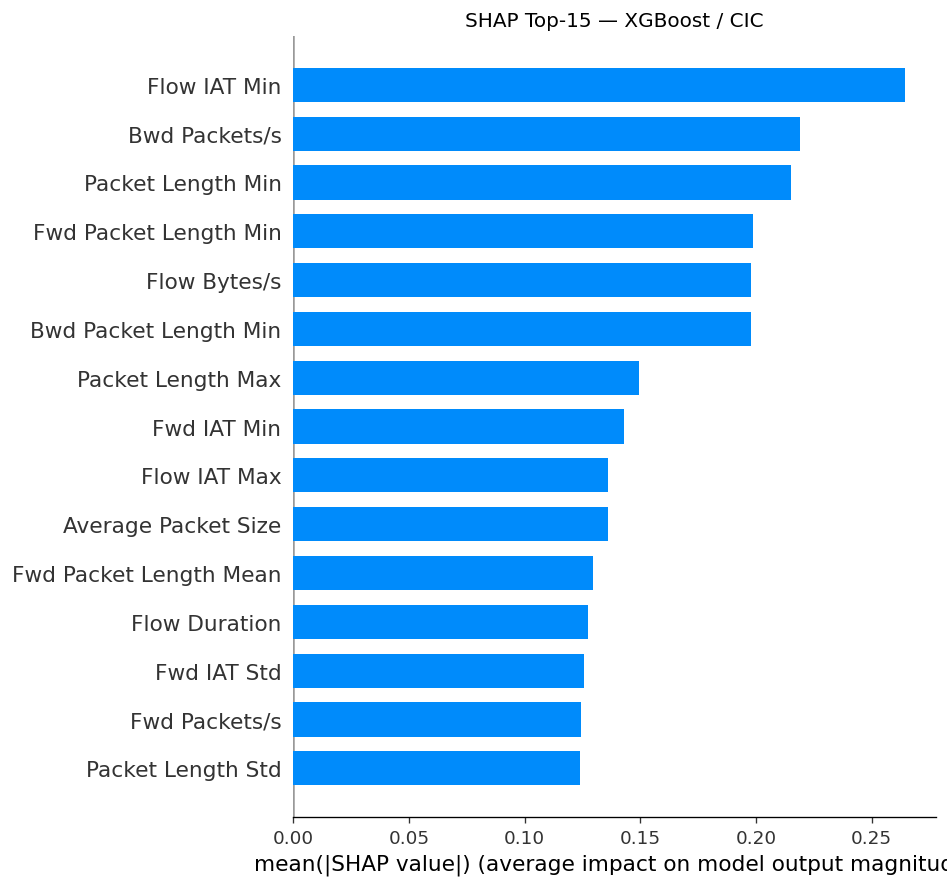


  XGBoost — Nemea
  ⚠ Columnas-lista eliminadas: ['uint32* DBI_BRST_BYTES', 'uint32* DBI_BRST_PACKETS', 'uint32* SBI_BRST_BYTES', 'uint32* SBI_BRST_PACKETS']
[Nemea] Shape X: (27848, 144) | Clases: 8
  Constantes eliminadas: 1

  [Nemea] Entrenando XGBoost...
  [Nemea] F1 macro (test): 0.5846


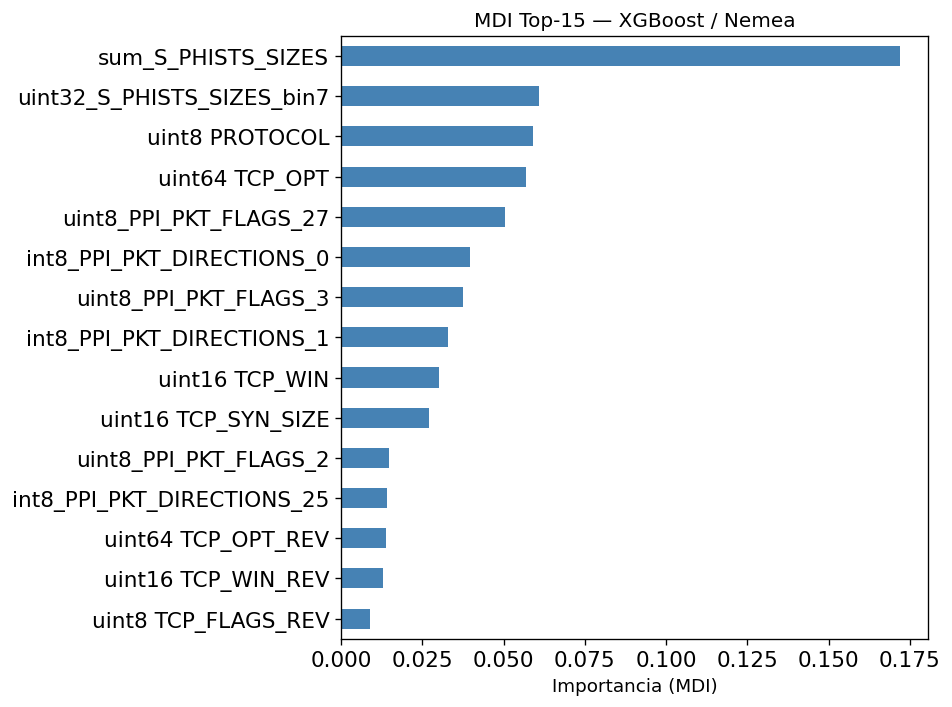

  [Nemea] Calculando SHAP...
  [Nemea] SHAP OK (booster limpio)


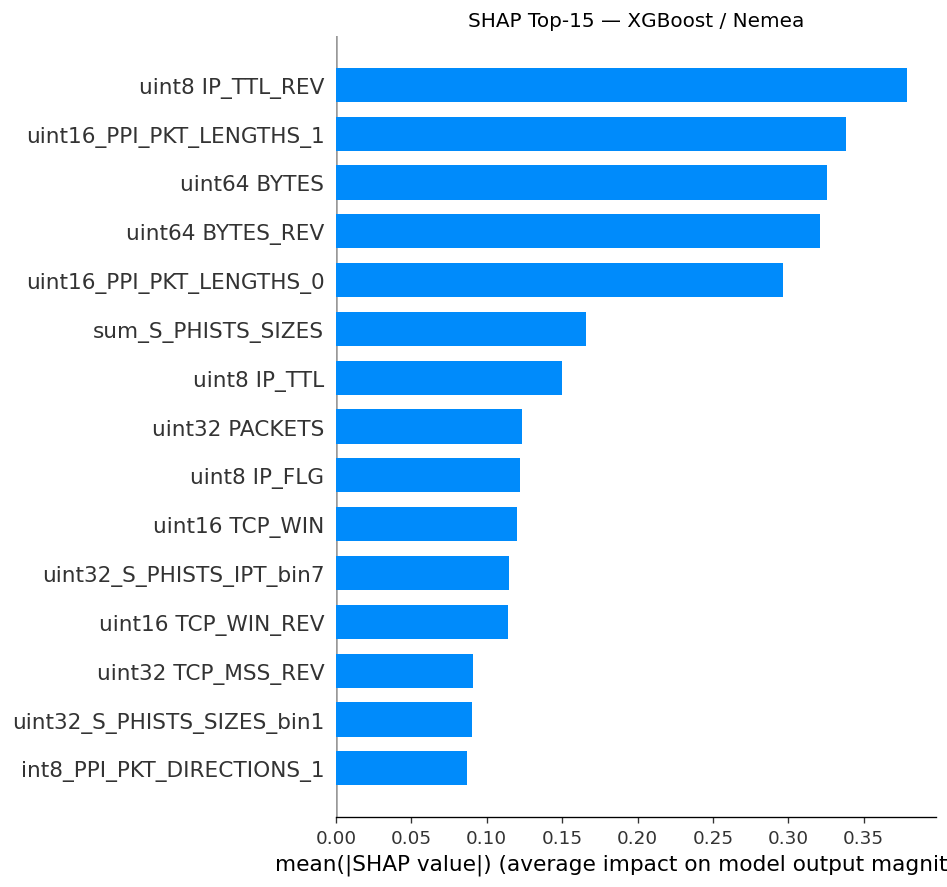


  XGBoost — Tstat
[Tstat] Shape X: (27848, 96) | Clases: 8
  Constantes eliminadas: 14

  [Tstat] Entrenando XGBoost...
  [Tstat] F1 macro (test): 0.6289


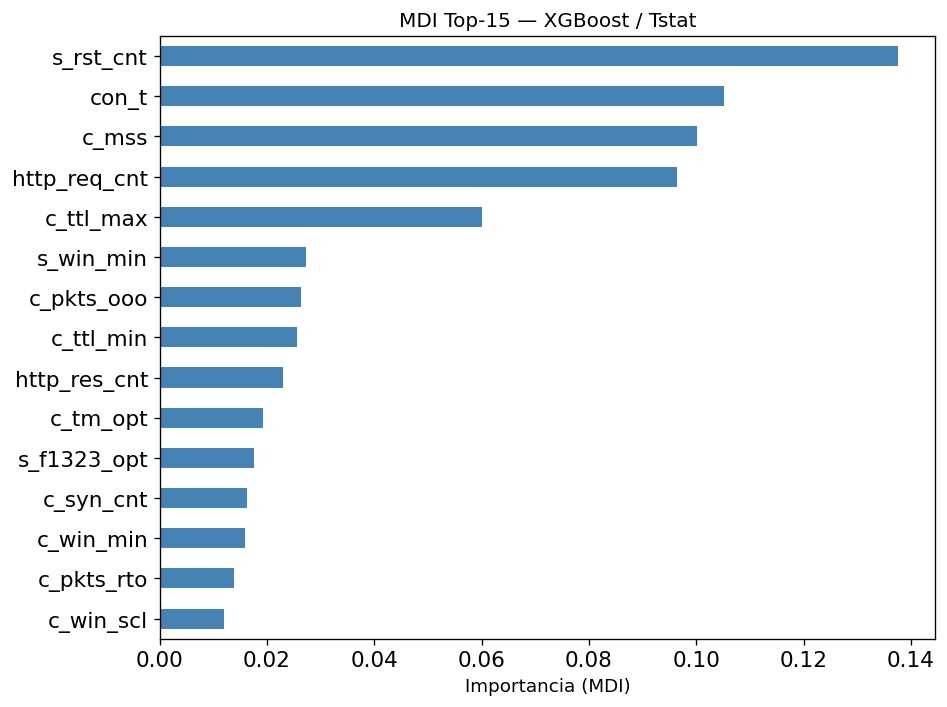

  [Tstat] Calculando SHAP...
  [Tstat] SHAP OK (booster limpio)


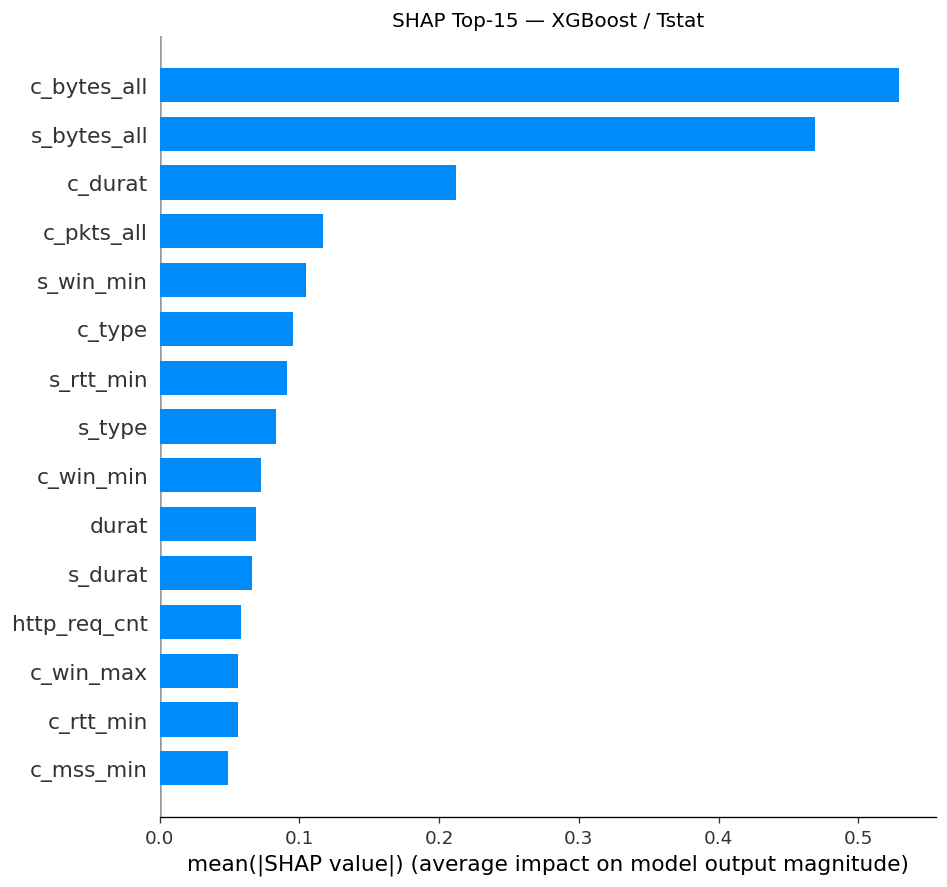


  XGBoost — Tshark
[Tshark] Shape X: (27848, 50) | Clases: 8
  Constantes eliminadas: 7

  [Tshark] Entrenando XGBoost...
  [Tshark] F1 macro (test): 0.7558


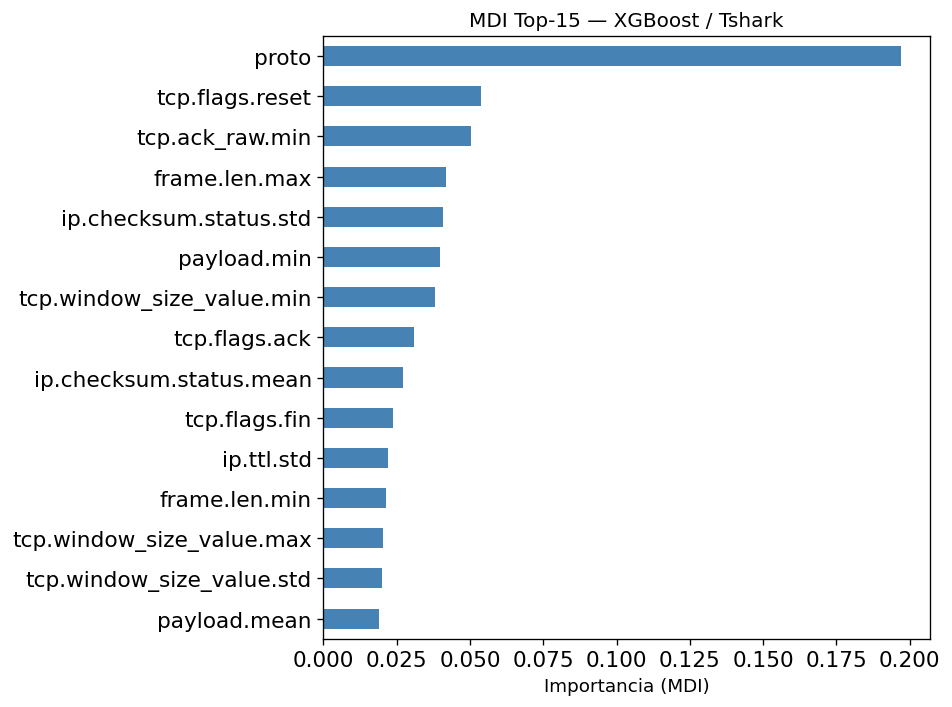

  [Tshark] Calculando SHAP...
  [Tshark] SHAP OK (booster limpio)


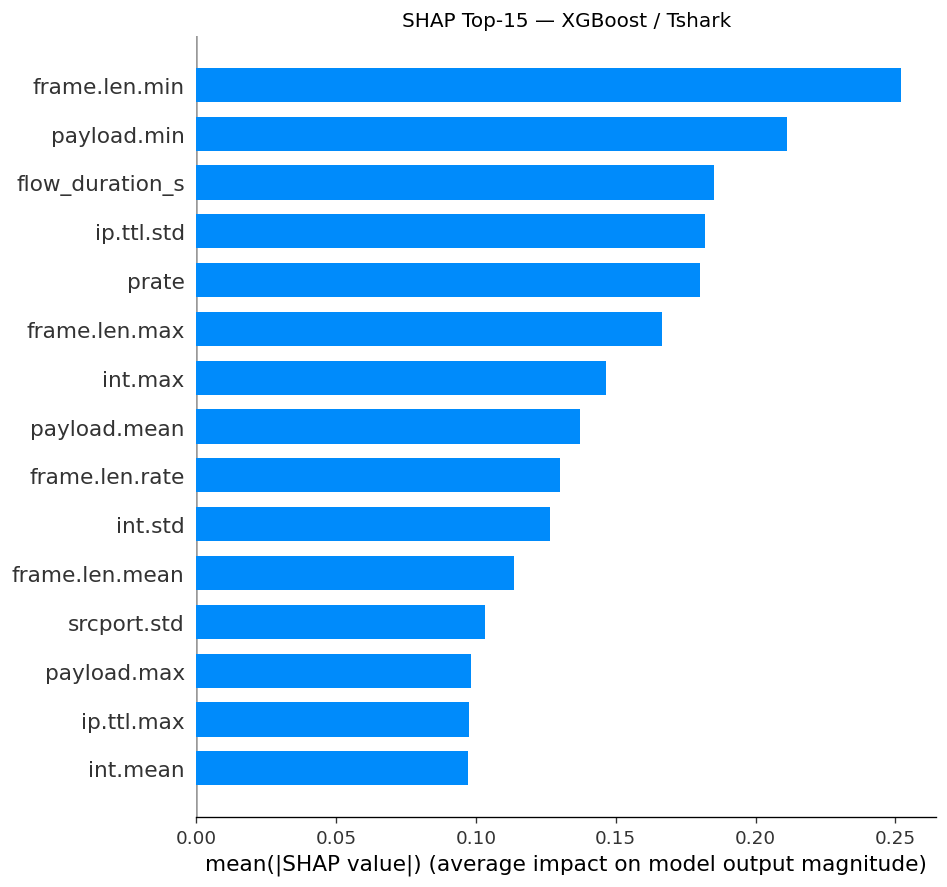


✓ XGBoost completado


In [15]:
# ============================================================
# CELDA 4 — XGBOOST
# Mejores hiperparámetros Optuna (100 trials)
# ============================================================

MEJORES_XGB = {
    'CIC':    dict(n_estimators=417, max_depth=4,  learning_rate=0.13294, subsample=0.6562,
                   colsample_bytree=0.9382, min_child_weight=3, gamma=0.3948, reg_alpha=1.3645, reg_lambda=2.6484),
    'Nemea':  dict(n_estimators=465, max_depth=12, learning_rate=0.24784, subsample=0.8865,
                   colsample_bytree=0.8113, min_child_weight=3, gamma=0.1589, reg_alpha=0.0851, reg_lambda=0.3111),
    'Tstat':  dict(n_estimators=428, max_depth=12, learning_rate=0.08017, subsample=0.7716,
                   colsample_bytree=0.8071, min_child_weight=3, gamma=0.4122, reg_alpha=0.1602, reg_lambda=1.2185),
    'Tshark': dict(n_estimators=563, max_depth=11, learning_rate=0.03515, subsample=0.9964,
                   colsample_bytree=0.7070, min_child_weight=4, gamma=0.2291, reg_alpha=0.2862, reg_lambda=2.5680),
}

resultados_xgb = []

for herramienta in HERRAMIENTAS:
    sep = '='*55; print(f'\n{sep}')
    print(f'  XGBoost — {herramienta}')
    print(sep)
    X, y, feature_names = cargar_herramienta(herramienta)
    kwargs = {**MEJORES_XGB[herramienta],
              'tree_method': 'hist', 'random_state': SEED,
              'n_jobs': 4, 'eval_metric': 'mlogloss', 'verbosity': 0}
    res = analizar_modelo('XGBoost', XGBClassifier, kwargs, herramienta, X, y, feature_names)
    resultados_xgb.append(res)

print('\n✓ XGBoost completado')


In [16]:
# ============================================================
# CELDA 5 — TABLA RESUMEN (XGBoost)
# ============================================================

print('\n' + '='*70)
print('  RESUMEN TOP-5 SHAP — XGBoost × 4 herramientas')
print('='*70)

for res in resultados_xgb:
    top15 = res['shap_top'].head(15)
    features_str = ', '.join(top15.index.tolist()) if len(top15) else 'N/A'
    print(f'  {res["herramienta"]:8s} (F1={res["f1"]:.4f}): {features_str}')

filas = []
for res in resultados_xgb:
    for rank, (feat, val) in enumerate(res['shap_top'].items(), 1):
        filas.append({
            'Modelo': res['modelo'],
            'Herramienta': res['herramienta'],
            'F1 macro': round(res['f1'], 4),
            'Rank SHAP': rank,
            'Feature': feat,
            'SHAP medio': round(float(val), 6)
        })

df_resumen_xgb = pd.DataFrame(filas)
ruta_csv = RUTA_FIGURAS / 'shap_resumen_XGBoost.csv'
df_resumen_xgb.to_csv(ruta_csv, index=False)
print(f'\n✓ Resumen guardado en {ruta_csv}')
df_resumen_xgb[df_resumen_xgb['Rank SHAP'] <= 15]



  RESUMEN TOP-5 SHAP — XGBoost × 4 herramientas
  CIC      (F1=0.7380): Flow IAT Min, Bwd Packets/s, Packet Length Min, Fwd Packet Length Min, Flow Bytes/s, Bwd Packet Length Min, Packet Length Max, Fwd IAT Min, Flow IAT Max, Average Packet Size, Fwd Packet Length Mean, Flow Duration, Fwd IAT Std, Fwd Packets/s, Packet Length Std
  Nemea    (F1=0.5846): uint8 IP_TTL_REV, uint16_PPI_PKT_LENGTHS_1, uint64 BYTES, uint64 BYTES_REV, uint16_PPI_PKT_LENGTHS_0, sum_S_PHISTS_SIZES, uint8 IP_TTL, uint32 PACKETS, uint8 IP_FLG, uint16 TCP_WIN, uint32_S_PHISTS_IPT_bin7, uint16 TCP_WIN_REV, uint32 TCP_MSS_REV, uint32_S_PHISTS_SIZES_bin1, int8_PPI_PKT_DIRECTIONS_1
  Tstat    (F1=0.6289): c_bytes_all, s_bytes_all, c_durat, c_pkts_all, s_win_min, c_type, s_rtt_min, s_type, c_win_min, durat, s_durat, http_req_cnt, c_win_max, c_rtt_min, c_mss_min
  Tshark   (F1=0.7558): frame.len.min, payload.min, flow_duration_s, ip.ttl.std, prate, frame.len.max, int.max, payload.mean, frame.len.rate, int.std, frame.le

,Modelo,Herramienta,F1 macro,Rank SHAP,Feature,SHAP medio
0,XGBoost,CIC,0.7380,1,Flow IAT Min,0.264588
1,XGBoost,CIC,0.7380,2,Bwd Packets/s,0.218874
2,XGBoost,CIC,0.7380,3,Packet Length Min,0.215002
3,XGBoost,CIC,0.7380,4,Fwd Packet Length Min,0.198859
4,XGBoost,CIC,0.7380,5,Flow Bytes/s,0.197807
5,XGBoost,CIC,0.7380,6,Bwd Packet Length Min,0.197654
6,XGBoost,CIC,0.7380,7,Packet Length Max,0.149435
7,XGBoost,CIC,0.7380,8,Fwd IAT Min,0.143090
8,XGBoost,CIC,0.7380,9,Flow IAT Max,0.136182
9,XGBoost,CIC,0.7380,10,Average Packet Size,0.135870


In [17]:
import xgboost as xgb
import shap
print(f'XGBoost: {xgb.__version__}')
print(f'SHAP:    {shap.__version__}')

# Ver qué hay exactamente en el config del booster
import json

# Entrena un modelo mínimo de prueba
from sklearn.datasets import make_classification
Xt, yt = make_classification(n_samples=100, n_features=5, n_classes=3, n_informative=3, random_state=42)
m = xgb.XGBClassifier(n_estimators=5, eval_metric='mlogloss', verbosity=0)
m.fit(Xt, yt)
booster = m.get_booster()
config = json.loads(booster.save_config())
lmp = config['learner']['learner_model_param']
print(f'\nbase_score en config: {repr(lmp.get("base_score"))}')
print(f'Tipo: {type(lmp.get("base_score"))}')

XGBoost: 2.1.4
SHAP:    0.49.1

base_score en config: '5E-1'
Tipo: <class 'str'>


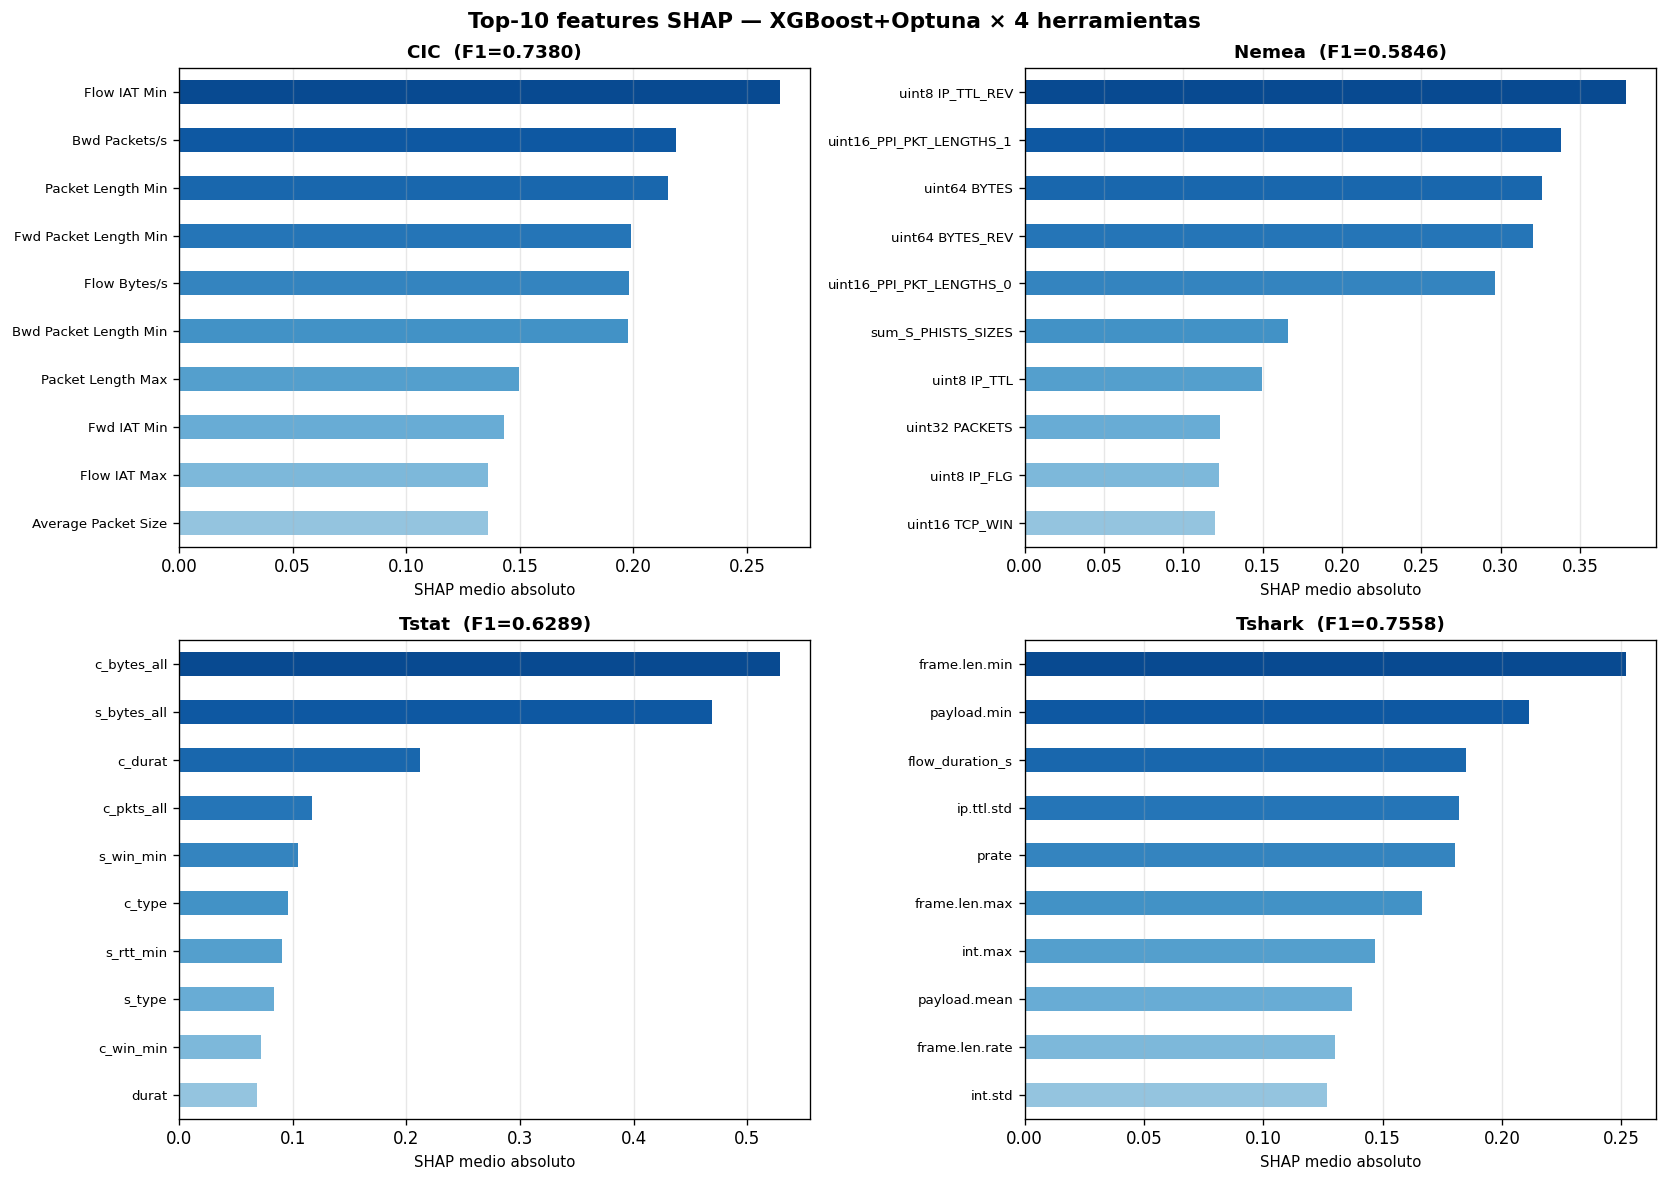

✓ Gráfico comparativo generado


In [18]:
# ============================================================
# CELDA 6 — GRÁFICO COMPARATIVO SHAP × 4 herramientas
# Solo disponible en el notebook de XGBoost
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, herramienta in enumerate(HERRAMIENTAS):
    res = next(r for r in resultados_xgb if r['herramienta'] == herramienta)
    top10 = res['shap_top'].head(10).sort_values()
    if len(top10) == 0:
        axes[i].set_title(f'{herramienta} — sin datos SHAP')
        continue
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top10)))
    top10.plot(kind='barh', ax=axes[i], color=colors)
    axes[i].set_title(f'{herramienta}  (F1={res["f1"]:.4f})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('SHAP medio absoluto', fontsize=9)
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].grid(axis='x', alpha=0.3)

fig.suptitle('Top-10 features SHAP — XGBoost+Optuna × 4 herramientas', fontsize=13, fontweight='bold')
plt.tight_layout()
if GUARDAR_FIGURAS:
    fig.savefig(RUTA_FIGURAS / 'SHAP_comparativo_XGBoost_4herramientas.pdf', dpi=150)
plt.show()
print('✓ Gráfico comparativo generado')



[CIC] Beeswarm con signo — XGBoost
  Rango SHAP: [-0.6260, 0.3891]
  Features con valores negativos: 66 de 69


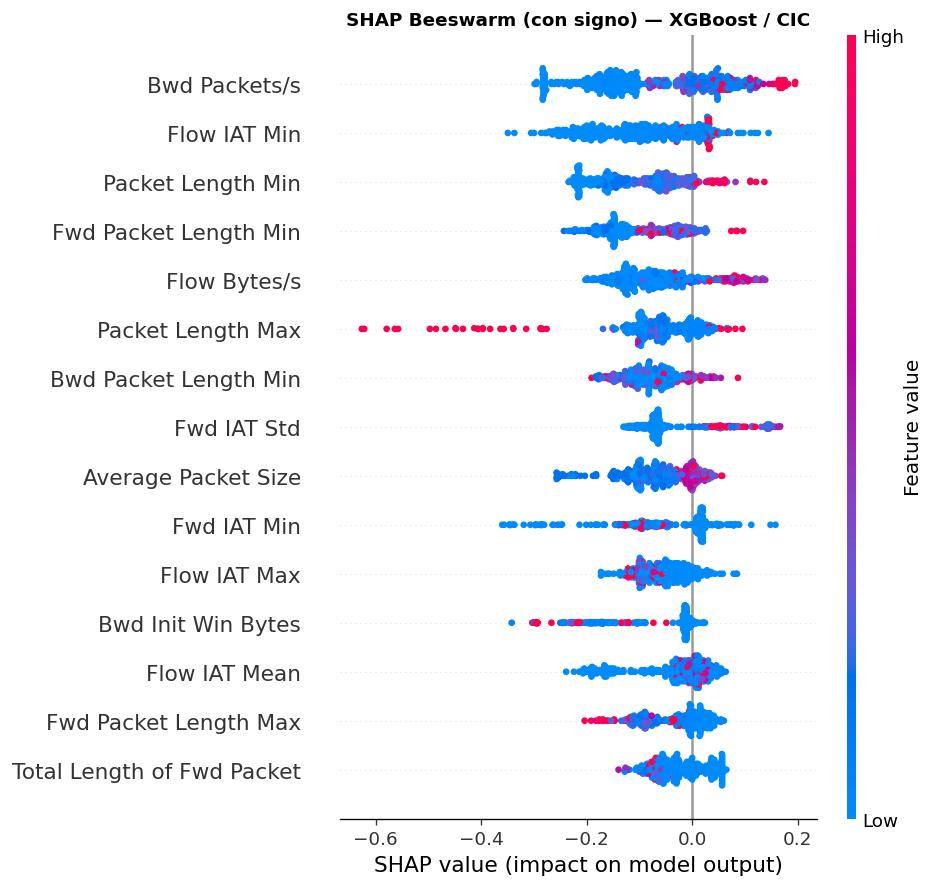

  Top contrafácticos (SHAP medio negativo):
    Packet Length Min                         -0.09948
    Fwd Packet Length Min                     -0.09673
    Flow IAT Min                              -0.09433
    Bwd Packet Length Min                     -0.07410
    Packet Length Max                         -0.06986

[Nemea] Beeswarm con signo — XGBoost
  Rango SHAP: [-0.7668, 0.3011]
  Features con valores negativos: 124 de 144


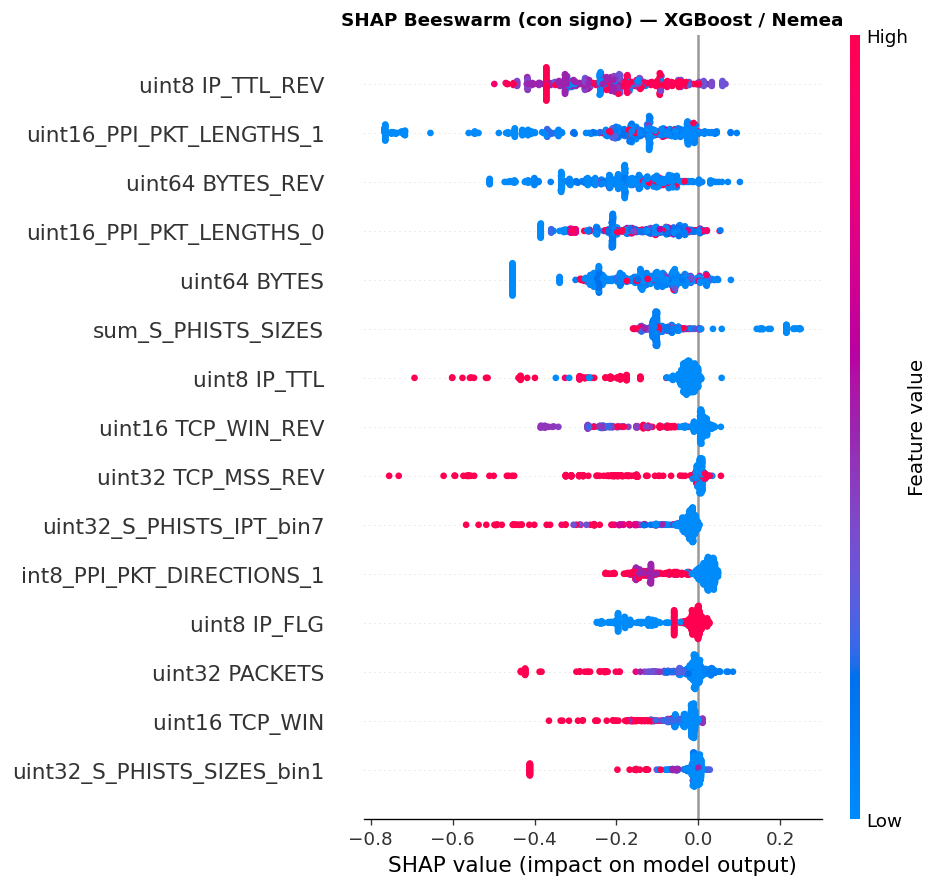

  Top contrafácticos (SHAP medio negativo):
    uint8 IP_TTL_REV                          -0.21401
    uint16_PPI_PKT_LENGTHS_1                  -0.20921
    uint64 BYTES_REV                          -0.17966
    uint16_PPI_PKT_LENGTHS_0                  -0.15807
    uint64 BYTES                              -0.15112

[Tstat] Beeswarm con signo — XGBoost
  Rango SHAP: [-0.8741, 0.3470]
  Features con valores negativos: 78 de 96


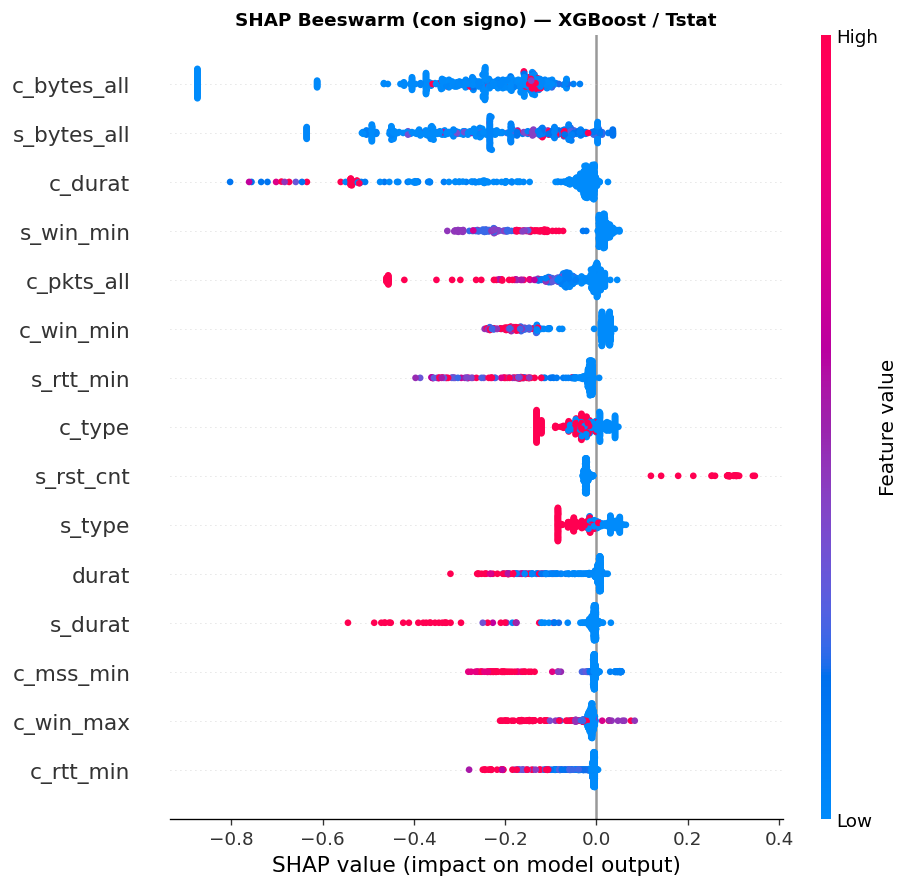

  Top contrafácticos (SHAP medio negativo):
    c_bytes_all                               -0.28002
    s_bytes_all                               -0.23667
    c_durat                                   -0.10902
    c_pkts_all                                -0.06283
    s_rtt_min                                 -0.05132

[Tshark] Beeswarm con signo — XGBoost
  Rango SHAP: [-0.6592, 0.3681]
  Features con valores negativos: 48 de 50


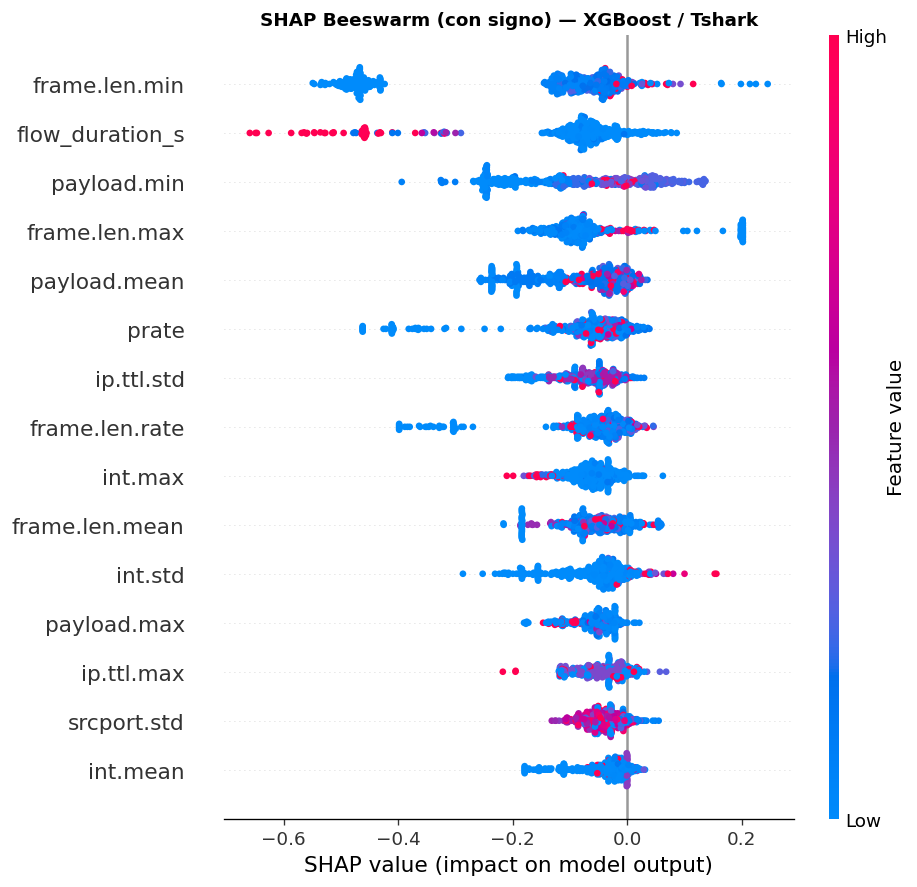

  Top contrafácticos (SHAP medio negativo):
    frame.len.min                             -0.17490
    flow_duration_s                           -0.11481
    payload.min                               -0.08909
    payload.mean                              -0.08534
    prate                                     -0.07809


In [19]:
# ============================================================
# CELDA NUEVA A — BEESWARM CON SIGNO (contrafácticos)
# Añadir al final del notebook, DESPUÉS de haber ejecutado
# el bucle principal (resultados_lgbm / resultados_rf / resultados_xgb)
#
# A diferencia del bar plot (que usa |SHAP|), el beeswarm
# conserva el signo: valores negativos = la feature ALEJA
# la predicción de esa clase (contrafácticos).
# El color indica el valor de la feature (rojo=alto, azul=bajo).
# ============================================================

def beeswarm_con_signo(resultados, nombre_modelo):
    """
    Genera un beeswarm plot por herramienta usando los shap_values
    con signo (sin valor absoluto). Requiere que analizar_modelo
    devuelva también 'shap_values_raw' y 'X_shap_raw'.
    
    NOTA: Esta celda necesita que la función analizar_modelo
    guarde shap_values y X_shap en el dict de resultados.
    Ver CELDA NUEVA B para la versión actualizada de analizar_modelo.
    """
    for res in resultados:
        herramienta = res['herramienta']
        shap_values = res.get('shap_values_raw')
        X_shap      = res.get('X_shap_raw')
        feature_names = res.get('feature_names')

        if shap_values is None:
            print(f'[{herramienta}] Sin shap_values_raw — saltando beeswarm.')
            continue

        # Para multiclase, shap_values puede ser:
        #   - lista de arrays (n_clases, n_muestras, n_features)  → RF/XGB old API
        #   - array 3D (n_muestras, n_features, n_clases)         → LightGBM new API
        # Aplanamos a (n_muestras, n_features) promediando sobre clases
        if isinstance(shap_values, list):
            # Lista de arrays (una por clase): shape cada uno = (n_muestras, n_features)
            sv_signed = np.mean(np.stack(shap_values, axis=0), axis=0)   # (n_muestras, n_features)
        elif shap_values.ndim == 3:
            # (n_muestras, n_features, n_clases) — LightGBM TreeExplainer nuevo
            sv_signed = shap_values.mean(axis=2)                          # (n_muestras, n_features)
        else:
            sv_signed = shap_values                                        # ya 2D

        print(f'\n[{herramienta}] Beeswarm con signo — {nombre_modelo}')
        print(f'  Rango SHAP: [{sv_signed.min():.4f}, {sv_signed.max():.4f}]')
        print(f'  Features con valores negativos: '
              f'{(sv_signed.mean(axis=0) < 0).sum()} de {sv_signed.shape[1]}')

        fig, ax = plt.subplots(figsize=(9, 7))
        shap.summary_plot(
            sv_signed,
            X_shap,
            feature_names=feature_names,
            max_display=TOP_N,
            plot_type='dot',      # beeswarm con signo; NO usar 'bar' aquí
            show=False,
            color_bar=True,
        )
        plt.title(f'SHAP Beeswarm (con signo) — {nombre_modelo} / {herramienta}',
                  fontsize=11, fontweight='bold')
        plt.tight_layout()
        if GUARDAR_FIGURAS:
            fig.savefig(RUTA_FIGURAS / f'SHAP_beeswarm_{nombre_modelo}_{herramienta}.pdf', dpi=150)
        plt.show()
        plt.close()

        # Resumen textual de contrafácticos (features con SHAP medio < 0)
        sv_mean = sv_signed.mean(axis=0)
        negativos = pd.Series(sv_mean, index=feature_names)
        negativos = negativos[negativos < 0].sort_values()
        if len(negativos):
            print(f'  Top contrafácticos (SHAP medio negativo):')
            for feat, val in negativos.head(5).items():
                print(f'    {feat:40s}  {val:.5f}')
        else:
            print(f'  No hay features con SHAP medio negativo (promedio sobre clases).')


# Cambia aquí el nombre según el notebook que estés ejecutando:
#   resultados_lgbm   → LightGBM
#   resultados_rf     → RF
#   resultados_xgb    → XGBoost
beeswarm_con_signo(resultados_xgb, 'XGBoost')






  COMPARACIÓN MDI vs SHAP — XGBoost

  [CIC]
  Rank  Feature MDI                          Feature SHAP                       
  ----  -----------------------------------  -----------------------------------
     1  Fwd Segment Size Avg                 Flow IAT Min                          
     2  Fwd PSH Flags                        Bwd Packets/s                         
     3  FWD Init Win Bytes                   Packet Length Min                     
     4  Protocol                             Fwd Packet Length Min                 
     5  Subflow Bwd Packets                  Flow Bytes/s                          
     6  Fwd Packet Length Min                Bwd Packet Length Min                 
     7  Fwd IAT Std                          Packet Length Max                     
     8  SYN Flag Count                       Fwd IAT Min                           
     9  Total Bwd packets                    Flow IAT Max                          
    10  Fwd Act Data Pkts           

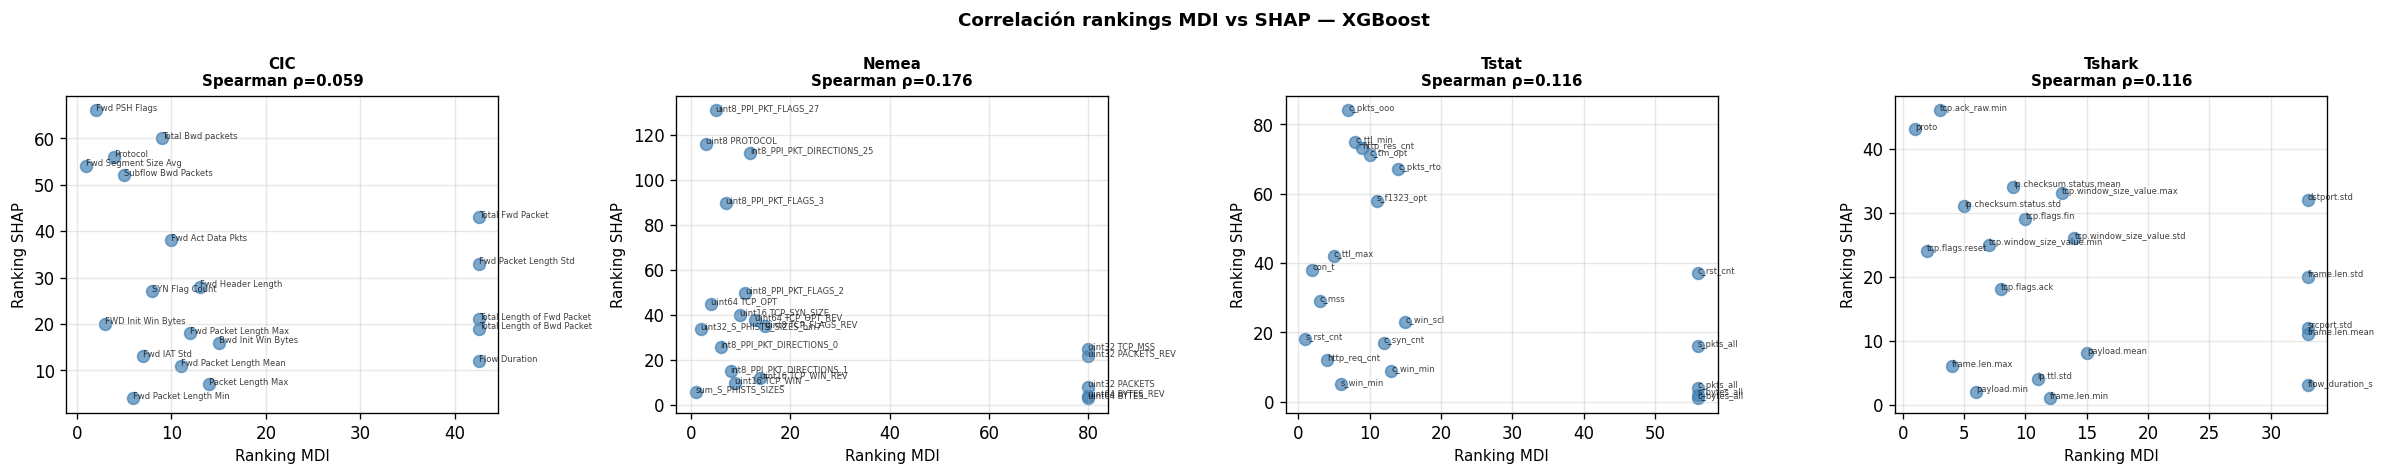


  RESUMEN GLOBAL (XGBoost):
  Herramienta  Spearman ρ    Coincid. top-5   Coincid. top-10  Conclusión
  ----------  ------------  ---------------  ---------------  --------------------
  CIC                0.059  0/5             1/10            Ortogonales
  Nemea              0.176  0/5             2/10            Ortogonales
  Tstat              0.116  0/5             1/10            Ortogonales
  Tshark             0.116  0/5             2/10            Ortogonales


In [20]:
# ============================================================
# CELDA NUEVA C — COMPARACIÓN MDI vs SHAP
# Tabla ranking lado a lado + scatter de correlación de Spearman
# ============================================================

import scipy.stats as stats

def comparar_mdi_vs_shap(resultados, nombre_modelo):
    """
    Para cada herramienta:
      1. Muestra tabla Top-15 MDI vs Top-15 SHAP lado a lado
      2. Scatter correlación de Spearman entre rankings MDI y SHAP
         sobre todas las features comunes
    """
    print(f'\n{"="*65}')
    print(f'  COMPARACIÓN MDI vs SHAP — {nombre_modelo}')
    print(f'{"="*65}')

    fig_scatter, axes = plt.subplots(1, len(resultados), figsize=(5 * len(resultados), 4))
    if len(resultados) == 1:
        axes = [axes]

    for ax, res in zip(axes, resultados):
        herramienta = res['herramienta']
        mdi_top     = res.get('mdi_top')      # pd.Series top-N MDI
        shap_top    = res.get('shap_top')     # pd.Series top-10 SHAP

        if mdi_top is None or shap_top is None or len(shap_top) == 0:
            print(f'[{herramienta}] Sin datos MDI o SHAP — saltando.')
            ax.set_visible(False)
            continue

        # ── Tabla lado a lado ─────────────────────────────────
        mdi_full  = mdi_top          # ya es top-N completa de la herramienta
        shap_full = shap_top         # top-10 guardada

        print(f'\n  [{herramienta}]')
        print(f'  {"Rank":>4}  {"Feature MDI":35s}  {"Feature SHAP":35s}')
        print(f'  {"-"*4}  {"-"*35}  {"-"*35}')
        for i in range(min(10, len(mdi_full), len(shap_full))):
            feat_mdi  = mdi_full.index[i]  if i < len(mdi_full)  else ''
            feat_shap = shap_full.index[i] if i < len(shap_full) else ''
            marca = '✓' if feat_mdi == feat_shap else ' '
            print(f'  {i+1:>4}  {feat_mdi:35s}  {feat_shap:35s}  {marca}')

        # Coincidencia top-5 y top-10
        mdi_set5   = set(mdi_full.index[:5])
        shap_set5  = set(shap_full.index[:5])
        mdi_set10  = set(mdi_full.index[:10])
        shap_set10 = set(shap_full.index[:10])
        print(f'  Coincidencia top-5:  {len(mdi_set5 & shap_set5)}/5 features')
        print(f'  Coincidencia top-10: {len(mdi_set10 & shap_set10)}/10 features')

        # ── Scatter Spearman sobre features comunes ───────────
        # Usamos el ranking completo MDI vs importancia SHAP sobre las mismas features
        feature_names = res.get('feature_names', list(mdi_top.index))
        mdi_serie  = res['mdi_top'].reindex(feature_names).fillna(0)

        # shap_top solo tiene top-10; reconstruimos la serie completa desde shap_values_raw
        shap_values = res.get('shap_values_raw')
        X_shap      = res.get('X_shap_raw')

        if shap_values is not None:
            if isinstance(shap_values, list):
                shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
            elif shap_values.ndim == 3:
                shap_abs_mean = np.mean(np.abs(shap_values), axis=2)
            else:
                shap_abs_mean = np.abs(shap_values)
            shap_serie = pd.Series(shap_abs_mean.mean(axis=0), index=feature_names)
        else:
            shap_serie = shap_top.reindex(feature_names).fillna(0)

        # Rankings (1 = más importante)
        rk_mdi  = mdi_serie.rank(ascending=False)
        rk_shap = shap_serie.rank(ascending=False)

        corr, pval = stats.spearmanr(rk_mdi, rk_shap)
        print(f'  Spearman MDI–SHAP:   ρ={corr:.3f}  (p={pval:.2e})')

        # Scatter solo top-20 de MDI para legibilidad
        top20 = mdi_serie.nlargest(20).index
        ax.scatter(rk_mdi[top20], rk_shap[top20], alpha=0.7, s=50, color='steelblue')
        for feat in top20:
            ax.annotate(feat, (rk_mdi[feat], rk_shap[feat]),
                        fontsize=5, alpha=0.75, ha='left')
        ax.set_xlabel('Ranking MDI', fontsize=9)
        ax.set_ylabel('Ranking SHAP', fontsize=9)
        ax.set_title(f'{herramienta}\nSpearman ρ={corr:.3f}', fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3)

    fig_scatter.suptitle(f'Correlación rankings MDI vs SHAP — {nombre_modelo}',
                         fontsize=11, fontweight='bold')
    plt.tight_layout()
    if GUARDAR_FIGURAS:
        fig_scatter.savefig(RUTA_FIGURAS / f'MDI_vs_SHAP_scatter_{nombre_modelo}.pdf', dpi=150)
    plt.show()
    plt.close()

    # ── Tabla global: ¿son ortogonales o coinciden? ──────────
    print(f'\n  RESUMEN GLOBAL ({nombre_modelo}):')
    print(f'  {"Herramienta":10s}  {"Spearman ρ":12s}  {"Coincid. top-5":15s}  {"Coincid. top-10":15s}  Conclusión')
    print(f'  {"-"*10}  {"-"*12}  {"-"*15}  {"-"*15}  {"-"*20}')

    for res in resultados:
        herramienta = res['herramienta']
        mdi_full  = res.get('mdi_top')
        shap_full = res.get('shap_top')
        if mdi_full is None or shap_full is None or len(shap_full) == 0:
            continue

        feature_names = res.get('feature_names', list(mdi_full.index))
        mdi_serie  = mdi_full.reindex(feature_names).fillna(0)

        shap_values = res.get('shap_values_raw')
        if shap_values is not None:
            if isinstance(shap_values, list):
                shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
            elif shap_values.ndim == 3:
                shap_abs_mean = np.mean(np.abs(shap_values), axis=2)
            else:
                shap_abs_mean = np.abs(shap_values)
            shap_serie = pd.Series(shap_abs_mean.mean(axis=0), index=feature_names)
        else:
            shap_serie = shap_full.reindex(feature_names).fillna(0)

        rk_mdi  = mdi_serie.rank(ascending=False)
        rk_shap = shap_serie.rank(ascending=False)
        corr, _ = stats.spearmanr(rk_mdi, rk_shap)

        c5  = len(set(mdi_full.index[:5])  & set(shap_full.index[:5]))
        c10 = len(set(mdi_full.index[:10]) & set(shap_full.index[:10]))

        if corr > 0.7:
            conclusion = 'Coinciden (ρ alto)'
        elif corr > 0.4:
            conclusion = 'Parcialmente'
        else:
            conclusion = 'Ortogonales'

        print(f'  {herramienta:10s}  {corr:12.3f}  {c5}/5{" ":11s}  {c10}/10{" ":10s}  {conclusion}')


# Cambia aquí el nombre según el notebook:
comparar_mdi_vs_shap(resultados_xgb, 'XGBoost')